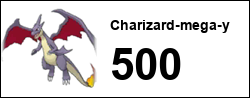

In [116]:
import pypokedex
import requests
from PIL import Image, ImageDraw, ImageFont
from io import BytesIO

def create_pokemon_image(pokemon_name, power, front = False, shiny_or_default = 'default'):
    # Create a blank image (250x98) with white background
    blank_image = Image.new('RGB', (250, 98), (255, 255, 255))

    sprite_image = Image.new('RGB', (96, 96), (0, 0, 0)).convert("RGBA")
    try:
        pokemon = pypokedex.get(name=pokemon_name.lower())
        if not front:
            try:
                sprite_url = pokemon.sprites.back[shiny_or_default]
                response = requests.get(sprite_url)
            except:
                sprite_url = pokemon.sprites.front[shiny_or_default]
                response = requests.get(sprite_url)
        else:
            sprite_url = pokemon.sprites.front[shiny_or_default]
            response = requests.get(sprite_url)
        # Fetch the sprite imag
        sprite_image = Image.open(BytesIO(response.content)).convert("RGBA")
    except:
        pass

    # Resize sprite if needed to fit the blank image (optional)
    sprite_image = sprite_image.resize((96, 96))  # Resize to 96x96 to match blank image height

    # Paste the sprite on the left side of the blank image (use alpha for transparency)
    blank_image.paste(sprite_image, (1, 1), sprite_image)

    # Prepare to add text
    draw = ImageDraw.Draw(blank_image)

    # Load bold font for the name and a larger font for the power number
    try:
        if len(pokemon_name) > 12:
            font_bold = ImageFont.truetype("arialbd.ttf", 14)  # Smaller font if the name is longer than 12 characters
        else:
            font_bold = ImageFont.truetype("arialbd.ttf", 24)  # Regular bold font for shorter names

        font_large = ImageFont.truetype("arialbd.ttf", 44)  # Larger bold font for power number
    except IOError:
        font_bold = ImageFont.load_default()  # Fallback to default font if custom font isn't available
        font_large = ImageFont.load_default()

    # Add the Pokémon name to the right of the sprite
    if len(pokemon_name) > 12:
        draw.text((110, 17), pokemon_name, fill="black", font=font_bold)  # Position (110, 17)
    else:
        draw.text((110, 10), pokemon_name, fill="black", font=font_bold)  # Position (110, 10)

    # Add the power number below the name with larger font
    draw.text((110, 40), str(power), fill="black", font=font_large)  # Position (110, 40)

    # Add 2-pixel wide black lines for the border (top, bottom, left, right)
    border_width = 1
    image_width, image_height = blank_image.size

    # Draw top line
    draw.line([(0, 0), (image_width, 0)], fill="black", width=border_width)
    # Draw bottom line
    draw.line([(0, image_height - 1), (image_width, image_height - 1)], fill="black", width=border_width)
    # Draw left line
    draw.line([(0, 0), (0, image_height)], fill="black", width=border_width)
    # Draw right line
    draw.line([(image_width - 1, 0), (image_width - 1, image_height)], fill="black", width=border_width)

    # Save or display the image
    return blank_image


# Example usage:
create_pokemon_image("Charizard-mega-y", 500,False, 'shiny')
#create_pokemon_image("Pikachu", 222)

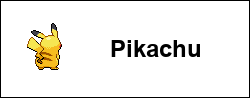

In [106]:
def create_pokemon_name_image(pokemon_name, front = True, shiny_or_default = 'default'):
    # Create a blank image (250x96) with white background
    blank_image = Image.new('RGB', (250, 98), (255, 255, 255))

    # Get Pokémon sprite using pypokedex
  # Convert name to lowercase for pypokedex

    sprite_image = Image.new('RGB', (96, 96), (0, 0, 0)).convert("RGBA")
    try:
        pokemon = pypokedex.get(name=pokemon_name.lower())
        if not front:
            try:
                sprite_url = pokemon.sprites.back[shiny_or_default]
                response = requests.get(sprite_url)
            except:
                sprite_url = pokemon.sprites.front[shiny_or_default]
                response = requests.get(sprite_url)
        else:
            sprite_url = pokemon.sprites.front[shiny_or_default]
            response = requests.get(sprite_url)
        # Fetch the sprite imag
        sprite_image = Image.open(BytesIO(response.content)).convert("RGBA")
    except:
        pass


    # Resize sprite if needed to fit the blank image (optional)
    sprite_image = sprite_image.resize((96, 96))  # Resize to 96x96 to match blank image height

    # Paste the sprite on the left side of the blank image (use alpha for transparency)
    blank_image.paste(sprite_image, (1, 1), sprite_image)

    # Prepare to add text
    draw = ImageDraw.Draw(blank_image)

    # Load bold font for the name
    try:
        if len(pokemon_name) > 12:
            font_bold = ImageFont.truetype("arialbd.ttf", 14)  # Smaller font if the name is longer than 12 characters
        else:
            font_bold = ImageFont.truetype("arialbd.ttf", 24)  # Regular bold font for shorter names
    except IOError:
        font_bold = ImageFont.load_default()  # Fallback to default font if custom font isn't available

    # Add the Pokémon name to the right of the sprite
    if len(pokemon_name) > 12:
        draw.text((110, 40), pokemon_name, fill="black", font=font_bold)  # Center the name vertically
    else:
        draw.text((110, 35), pokemon_name, fill="black", font=font_bold)  # Center the name vertically

    # Add 2-pixel wide black lines for the border (top, bottom, left, right)
    border_width = 1
    image_width, image_height = blank_image.size

    # Draw top line
    draw.line([(0, 0), (image_width, 0)], fill="black", width=border_width)
    # Draw bottom line
    draw.line([(0, image_height - 1), (image_width, image_height - 1)], fill="black", width=border_width)
    # Draw left line
    draw.line([(0, 0), (0, image_height)], fill="black", width=border_width)
    # Draw right line
    draw.line([(image_width - 1, 0), (image_width - 1, image_height)], fill="black", width=border_width)

    # Save or display the image
    return blank_image

create_pokemon_name_image('Pikachu', front = False)

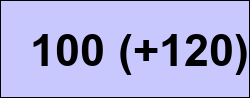

In [133]:
from PIL import Image, ImageDraw, ImageFont

def create_text_image(text, background_color):
    # Create a blank image (250x96) with the specified background color
    image = Image.new('RGB', (250, 98), background_color)

    # Prepare to add text
    draw = ImageDraw.Draw(image)

    # Load bold font for the text
    try:
        if len(text) > 10:
            font = ImageFont.truetype("arialbd.ttf", 24)  # Smaller font if text is longer than 8 characters
        else:
            font = ImageFont.truetype("arialbd.ttf", 45)  # Regular font for short text
    except IOError:
        font = ImageFont.load_default()  # Fallback to default font if custom font isn't available

    # Add the text at a fixed position
    position = (30, 25)  # Fixed position for text
    draw.text(position, text, fill="black", font=font)
        # Add 2-pixel wide black lines for the border (top, bottom, left, right)
    border_width = 1
    image_width, image_height = image.size

    # Draw top line
    draw.line([(0, 0), (image_width, 0)], fill="black", width=border_width)
    # Draw bottom line
    draw.line([(0, image_height - 1), (image_width, image_height - 1)], fill="black", width=border_width)
    # Draw left line
    draw.line([(0, 0), (0, image_height)], fill="black", width=border_width)
    # Draw right line
    draw.line([(image_width - 1, 0), (image_width - 1, image_height)], fill="black", width=border_width)

    return image

# Example usage:
create_text_image("100 (+120)", (200, 200, 255))  # Light blue background


In [145]:
from PIL import Image, ImageDraw, ImageFont
import pandas as pd

# Assuming create_text_image and create_pokemon_image functions are defined as needed.

def create_pokemon_collage_alt(df, path=None, potenze=None):
    # Assuming all images have the same size (250x98)
    image_width = 250
    image_height = 98

    # Create a blank collage image with a grid layout (grid_size is a tuple of (rows, cols))
    num_rows, num_cols = df.shape
    collage_width = (num_cols-1) * image_width
    collage_height = (num_rows+1) * image_height
    collage_image = Image.new('RGB', (collage_width, collage_height), (255, 255, 255))  # White background

    name_image = create_text_image('Lega',(255,255,255))
    collage_image.paste(name_image, (0,0))
    
    for index, (pokemon_name, power) in enumerate(zip(df['Pokemon'].tolist(), df['Potenza Base'].tolist())):
        # Position for Pokémon name
        name_position = (0, (index+1) * image_height)
        # Create Pokémon name image
        name_image = create_pokemon_image(pokemon_name, power)
        collage_image.paste(name_image, name_position)

    # Loop through the remaining columns (ignoring 'Potenza Base')
    for col in range(2, num_cols):
        column_name = df.columns[col]  # Get column name (e.g., "Yanma (195)")
        
        
        pokemon_name = column_name  # Get Pokémon name from current column
        pokemon_name, power = pokemon_name.split(' ')
        power = int(power.replace('(','').replace(')',''))
        position = ((col-1) * image_width, 0)
        individual_image = create_pokemon_image(pokemon_name,power,True,'default')  # Create the Pokémon image
        collage_image.paste(individual_image, position)
        
        for index in range(num_rows):
            # Create blue background text for the Pokémon name
            position = ((col-1) * image_width, (index+1) * image_height)
            text_image = create_text_image(df[column_name][index], (166, 238, 166) )  # White text on blue
            collage_image.paste(text_image, position)
            # Yellow = (255, 255, 177)
            # Green = (166, 238, 166)
            # Red = (255, 144, 144)
        
    # Save or return the final collage image
    if path:
        collage_image.save(path)
    return collage_image

# Example usage
c = create_pokemon_collage_alt(df)
c.show()


In [90]:
import pandas as pd

# Define the data as a dictionary
data = {
    "Pokemon": ["Swampert", "Donphan", "Golduck", "Salamence", "Regirock", "Latios", "Registeel", "Regice", "Kyogre"],
    "Potenza Base": [530, 455, 425, 582, 505, 438, 534, 441, 598],
    "Yanma (195)": ["490 (-40)", "415 (-40)", "425 (0)", "642 (60)", "605 (100)", "398 (-40)", "574 (40)", "481 (40)", "598 (0)"],
    "Cacnea (265)": ["410 (-120)", "395 (-60)", "365 (-60)", "662 (80)", "465 (-40)", "458 (20)", "554 (20)", "481 (40)", "538 (-60)"],
    "Araquanid (363)": ["490 (-40)", "395 (-60)", "425 (0)", "662 (80)", "505 (0)", "418 (-20)", "534 (0)", "421 (-20)", "598 (0)"],
    "Alcremie (238)": ["530 (0)", "455 (0)", "425 (0)", "502 (-80)", "505 (0)", "358 (-80)", "594 (60)", "441 (0)", "598 (0)"],
    "Meowth (264)": ["530 (0)", "455 (0)", "425 (0)", "582 (0)", "525 (20)", "438 (0)", "554 (20)", "441 (0)", "598 (0)"],
    "Primarina (233)": ["510 (-20)", "415 (-40)", "425 (0)", "522 (-60)", "465 (-40)", "378 (-60)", "554 (20)", "421 (-20)", "598 (0)"],
    "Larvitar (21)": ["670 (140)", "515 (60)", "505 (80)", "562 (-20)", "445 (-60)", "438 (0)", "554 (20)", "441 (0)", "678 (80)"],
    "Silvally (23)": ["530 (0)", "455 (0)", "425 (0)", "582 (0)", "525 (20)", "438 (0)", "554 (20)", "441 (0)", "598 (0)"]
}

# Create the DataFrame
df = pd.DataFrame(data)

# Display the DataFrame
display(df)
print(df.shape)

,Pokemon,Potenza Base,Yanma (195),Cacnea (265),Araquanid (363),Alcremie (238),Meowth (264),Primarina (233),Larvitar (21),Silvally (23)
0,Swampert,530,490 (-40),410 (-120),490 (-40),530 (0),530 (0),510 (-20),670 (140),530 (0)
1,Donphan,455,415 (-40),395 (-60),395 (-60),455 (0),455 (0),415 (-40),515 (60),455 (0)
2,Golduck,425,425 (0),365 (-60),425 (0),425 (0),425 (0),425 (0),505 (80),425 (0)
3,Salamence,582,642 (60),662 (80),662 (80),502 (-80),582 (0),522 (-60),562 (-20),582 (0)
4,Regirock,505,605 (100),465 (-40),505 (0),505 (0),525 (20),465 (-40),445 (-60),525 (20)
5,Latios,438,398 (-40),458 (20),418 (-20),358 (-80),438 (0),378 (-60),438 (0),438 (0)
6,Registeel,534,574 (40),554 (20),534 (0),594 (60),554 (20),554 (20),554 (20),554 (20)
7,Regice,441,481 (40),481 (40),421 (-20),441 (0),441 (0),421 (-20),441 (0),441 (0)
8,Kyogre,598,598 (0),538 (-60),598 (0),598 (0),598 (0),598 (0),678 (80),598 (0)


(9, 10)
